In [ ]:
import os
import torch
import numpy as np
from itertools import combinations
from sklearn.metrics import roc_auc_score, average_precision_score

from alphagenome.data import genome
from alphagenome_research.model import dna_model
from alphagenome_research.model.dna_model import OrganismSettings
from alphagenome_research.io import fasta

# ==========================================
# 0. Extraction and Scoring Functions (Unchanged)
# ==========================================
def extract_and_aggregate_score(edge_local, matrix, node_map_inv, start_bin, agg_method='mean'):
    """
    Calculate scores for multi-way hyperedges based on AlphaGenome's Log(O/E) contact maps.
    """
    pairwise_scores = []
    
    # Extract all pairwise node combinations within the hyperedge
    for u_local, v_local in combinations(edge_local, 2):
        u_global = node_map_inv[u_local]
        v_global = node_map_inv[v_local]
        
        idx_u = u_global - start_bin
        idx_v = v_global - start_bin
        
        # Check if indices fall within the current 512x512 window
        if 0 <= idx_u < matrix.shape[0] and 0 <= idx_v < matrix.shape[1]:
            # Retrieve Log(O/E) value
            score = matrix[idx_u, idx_v]
            pairwise_scores.append(float(score))
        else:
            # Out-of-bounds padding with 0.0, representing Log(1) = 0 (neither specific enrichment nor penalty)
            pairwise_scores.append(0.0)
            
    if not pairwise_scores:
        return 0.0

    # Strategy A: Product of enrichments (sum of log scores)
    if agg_method == 'sum':
        return np.sum(pairwise_scores)
        
    # Strategy B: Geometric Mean of enrichments (mean of log scores)
    elif agg_method == 'mean':
        return np.mean(pairwise_scores)
        
    else:
        raise ValueError("Unsupported aggregation method")

# ==========================================
# 1. Configuration and Model Loading
# ==========================================
CHECKPOINT_PATH = '/lustre/home/yywu/alphagenome_research/weights/alphagenome-all-folds'
LOCAL_BASE = '/lustre/home/yywu/alphagenome_research/reference'

custom_settings = {
    dna_model.Organism.HOMO_SAPIENS: OrganismSettings(
        fasta_path=f'{LOCAL_BASE}/GRCh38.p13.genome.fa',
        gtf_feather_path=f'{LOCAL_BASE}/gencode.v46.annotation.gtf.gz.feather',
        pas_feather_path=f'{LOCAL_BASE}/polyadb_human_v3_exon3_contiguous_gtfv46.feather',
        splice_site_starts_feather_path=f'{LOCAL_BASE}/gencode.v46.splice_sites_starts.feather',
        splice_site_ends_feather_path=f'{LOCAL_BASE}/gencode.v46.splice_sites_ends.feather',
    )
}

print("Loading AlphaGenome model...")
model = dna_model.create(
    CHECKPOINT_PATH, 
    organism_settings=custom_settings, 
    device=None  # Recommend setting to 'cuda' if GPU is available to speed up
)
print("Model loaded successfully!")

# ==========================================
# 2. Initialize Score Storage Dictionary
# ==========================================
# Store scores separately for positive samples and 3 types of negative samples
scores_dict = {
    'pos': {'sum': [], 'mean': []},
    'sns': {'sum': [], 'mean': []},
    'mns': {'sum': [], 'mean': []},
    'cns': {'sum': [], 'mean': []}
}

# ==========================================
# 3. Main Evaluation Pipeline (Multi-Chromosome)
# ==========================================
BIN_SIZE = 2048
CELL_LINE_ONTOLOGY = 'EFO:0002784' 
CHROMOSOMES = ['chr14', 'chr22', 'chrX']
DATA_DIR = "gm12878_data"

for CHR_NAME in CHROMOSOMES:
    PT_FILE_PATH = os.path.join(DATA_DIR, f"{CHR_NAME}_all_windows.pt")
    
    if not os.path.exists(PT_FILE_PATH):
        print(f"⚠️ File not found: {PT_FILE_PATH}, skipping chromosome...")
        continue
        
    print(f"\n>>> Processing chromosome: {CHR_NAME} | File: {PT_FILE_PATH}")
    chrom_data = torch.load(PT_FILE_PATH, weights_only=False)
    
    # [::4] Extract non-overlapping windows
    for i, window in enumerate(chrom_data[::4]):
        start_bin, end_bin = window['window_range']
        node_map_inv = window['node_map_inv']
        
        pos_edges = window.get('pos_edges', [])
        sns_edges = window.get('sns_pool', [])
        mns_edges = window.get('mns_pool', [])
        cns_edges = window.get('cns_pool', [])
        
        if len(pos_edges) == 0:
            continue
            
        start_bp = start_bin * BIN_SIZE
        end_bp = end_bin * BIN_SIZE
        interval = genome.Interval(chromosome=CHR_NAME, start=start_bp, end=end_bp)
        
        try:
            # Predict
            outputs = model.predict_interval(
                interval=interval,
                organism=dna_model.Organism.HOMO_SAPIENS,
                ontology_terms=[CELL_LINE_ONTOLOGY],
                requested_outputs=[dna_model.OutputType.CONTACT_MAPS],
            )

            pred_map_tensor = outputs.contact_maps.values
            if isinstance(pred_map_tensor, torch.Tensor):
                pred_map = pred_map_tensor.squeeze().detach().cpu().numpy()
            else:
                pred_map = np.squeeze(pred_map_tensor)
                
            # if pred_map.min() < 0 or pred_map.max() > 1.0:
            #     pred_map = 1 / (1 + np.exp(-pred_map)) 
                
            # Helper function: compute and append scores in batch
            def evaluate_and_store(edges, category):
                for edge in edges:
                    s_prod = extract_and_aggregate_score(edge, pred_map, node_map_inv, start_bin, 'sum')
                    s_geom = extract_and_aggregate_score(edge, pred_map, node_map_inv, start_bin, 'mean')
                    scores_dict[category]['sum'].append(s_prod)
                    scores_dict[category]['mean'].append(s_geom)
            
            # Record scores for each category
            evaluate_and_store(pos_edges, 'pos')
            evaluate_and_store(sns_edges, 'sns')
            evaluate_and_store(mns_edges, 'mns')
            evaluate_and_store(cns_edges, 'cns')
            
        except Exception as e:
            print(f"Skipping window {window['window_idx']} on {CHR_NAME} due to error: {e}")

        # Progress update (prints every 10 non-overlapping windows)
        if (i + 1) % 10 == 0:
            print(f"[{CHR_NAME}] Processed {i + 1} / {len(chrom_data[::4])} windows...")

In [3]:
# ==========================================
# 4. Compute Independent Metrics (AUC & AUPR)
# ==========================================
print("\n" + "="*45)
print(" "*8 + "Final Multi-way Evaluation Results")
print("="*45)

pos_count = len(scores_dict['pos']['sum'])
print(f"Total positive hyperedges calculated: {pos_count}")

# Generate independent evaluation reports for each negative sample type
alphagenome_sum = []
alphagenome_mean = []
for neg_type in ['mns', 'sns', 'cns']:
    neg_count = len(scores_dict[neg_type]['sum'])
    if pos_count == 0 or neg_count == 0:
        print(f"\n[ {neg_type.upper()} Evaluation ]: Insufficient data (Pos={pos_count}, Neg={neg_count})")
        continue
        
    print(f"\n[ Positive vs {neg_type.upper()} Negative Evaluation ] (Neg count: {neg_count})")
    
    # Construct label array for the current task
    # Positives labeled as 1, negatives labeled as 0
    y_true_task = np.array([1]*pos_count + [0]*neg_count)
    
    # Concatenate scores
    y_pred_prod_task = np.array(scores_dict['pos']['sum'] + scores_dict[neg_type]['sum'])
    y_pred_geom_task = np.array(scores_dict['pos']['mean'] + scores_dict[neg_type]['mean'])
    
    # Calculate metrics for Strategy A (Product / Sum of log)
    auc_prod = roc_auc_score(y_true_task, y_pred_prod_task)
    aupr_prod = average_precision_score(y_true_task, y_pred_prod_task)
    
    # Calculate metrics for Strategy B (Geometric Mean / Mean of log)
    auc_geom = roc_auc_score(y_true_task, y_pred_geom_task)
    aupr_geom = average_precision_score(y_true_task, y_pred_geom_task)
    
    # Formatted printing
    print(f" └─ [Strategy A - Sum Aggregation]   AUC: {auc_prod:.4f}  |  AUPR: {aupr_prod:.4f}")
    print(f" └─ [Strategy B - Mean Aggregation]  AUC: {auc_geom:.4f}  |  AUPR: {aupr_geom:.4f}")

    alphagenome_sum.append(auc_prod)
    alphagenome_mean.append(auc_geom)

print("\n" + "="*45)


        Final Multi-way Evaluation Results
Total positive hyperedges calculated: 1978182

[ Positive vs MNS Negative Evaluation ] (Neg count: 3956364)
 └─ [Strategy A - Sum Aggregation]   AUC: 0.5010  |  AUPR: 0.3378
 └─ [Strategy B - Mean Aggregation]  AUC: 0.4964  |  AUPR: 0.3293

[ Positive vs SNS Negative Evaluation ] (Neg count: 3956364)
 └─ [Strategy A - Sum Aggregation]   AUC: 0.5864  |  AUPR: 0.4143
 └─ [Strategy B - Mean Aggregation]  AUC: 0.5862  |  AUPR: 0.4027

[ Positive vs CNS Negative Evaluation ] (Neg count: 3956364)
 └─ [Strategy A - Sum Aggregation]   AUC: 0.4614  |  AUPR: 0.3127
 └─ [Strategy B - Mean Aggregation]  AUC: 0.4642  |  AUPR: 0.3087



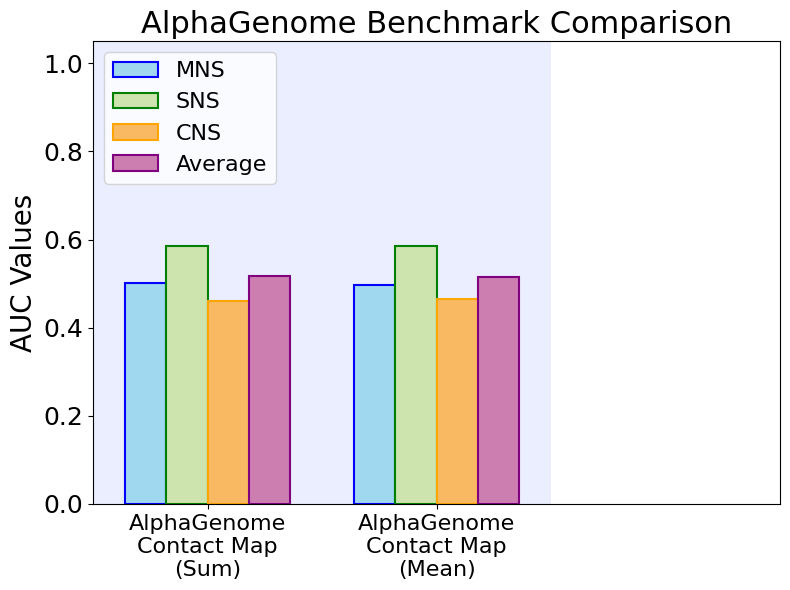

In [5]:
import matplotlib.pyplot as plt
import numpy as np

alphagenome_sum.append(np.mean(alphagenome_sum))
alphagenome_mean.append(np.mean(alphagenome_mean))

# AUC data
auc_data = {
    "AlphaGenome\nContact Map\n(Sum)": alphagenome_sum,
    "AlphaGenome\nContact Map\n(Mean)": alphagenome_mean,
#    "PHOCI\n(Ours)": []
}
##### Note: The results for "PHOCI (Ours)" are directly adapted from Fig.2(d–f), 
##### as AlphaGenome and PHOCI were evaluated under different computational environments.


labels = ['MNS', 'SNS', 'CNS', 'Average']
group_names = list(auc_data.keys())

# 参数设置
n_groups = len(group_names)  # 当前为 3 个模型
n_bars_per_group = len(labels)
bar_width = 0.18
x = np.arange(n_groups)

# 颜色设置 (完全沿用你原代码中的配色与描边)
colors = ['#a0d8ef', '#cee4ae', '#f8b962', '#cc7eb1']
edge_colors = ['blue', 'green', 'orange', 'purple']
background_colors = ['#dfe4ff', '#dfe4ff', '#dfe4ff']  # 3 个组对应的背景色块

# 创建画布
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制背景色块 (循环为 3 个模型分别铺上浅色底块)
for i in range(n_groups):
    ax.axvspan(i - 0.5, i + 0.5, facecolor=background_colors[i], alpha=0.6)

# 绘制柱状图
for i in range(n_bars_per_group):
    values = [auc_data[group][i] for group in group_names]
    ax.bar(x + i * bar_width - 1.5 * bar_width, values,
           width=bar_width, label=labels[i],
           color=colors[i], edgecolor=edge_colors[i], linewidth=1.5)

# 设置标签和标题
ax.set_xticks(x)
ax.set_xticklabels(group_names, fontsize=16)
ax.set_ylabel('AUC Values', fontsize=20)
ax.set_title('AlphaGenome Benchmark Comparison', fontsize=22)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.5, 2.5)  # 适配 3 个 Group 的范围
ax.tick_params(axis='y', labelsize=18)

# 图例设置
ax.legend(
    fontsize=16,
    loc='upper left',  # 放在左上角避免遮挡柱子
    frameon=True
)

# 美化布局并保存
plt.tight_layout()
#plt.savefig('panel_l_auc_comparison.png', dpi=300)
plt.show()